In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netpyne import sim, specs
import seaborn as sns

%matplotlib inline

savedata = 1 # Save Netpyne and BBP soma_voltage

In [169]:
!nrnivmodl mod/

/home/diogo/miniforge3/envs/p39_new/bin/nrnivmodl:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import working_set
/home/diogo/Dropbox/Diogo/H01_Network_model/cod/Human_L23_NetPyNE-main/sim
Mod files: "mod/mod//CaDynamics.mod" "mod/mod//Ca_HVA.mod" "mod/mod//Ca_LVA.mod" "mod/mod//epsp.mod" "mod/mod//Gfluct.mod" "mod/mod//Ih.mod" "mod/mod//Im.mod" "mod/mod//K_P.mod" "mod/mod//K_T.mod" "mod/mod//Kv3_1.mod" "mod/mod//Nap.mod" "mod/mod//NaTg.mod" "mod/mod//NMDA.mod" "mod/mod//ProbAMPANMDA.mod" "mod/mod//ProbUDFsyn.mod" "mod/mod//SK.mod" "mod/mod//tonic.mod"

 -> Compiling mod_func.cpp
 => LINKING shared library ./libnrnmech.so
Successfully created x86_64/special


# **CONFIGURATION**

In [2]:
cfg = specs.SimConfig()
cellName = 'HL23VIP'
cfg.duration = 3000  # Total simulation time (ms)
cfg.dt = 0.025       # Integration step (ms)
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1234, 'loc':4321}  
cfg.hParams = {'celsius': 34, 'v_init': -80}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cache_efficient = True

cfg.recordCells = [f'{cellName}_{i}' for i in range(1, 23)]  # Recording from all populations
cfg.recordTraces = {'V_soma': {'sec': 'soma_0', 'loc': 0.5, 'var': 'v'}}
cfg.recordStim = True
cfg.recordTime = True
cfg.recordStep = 0.025

cfg.simLabel = 'L23_PV'
cfg.saveFolder = '.'
cfg.savePickle = False
cfg.saveJson = False

# **NETWORK PARAMETERS**

In [3]:
netParams = specs.NetParams()

netParams.importCellParams(
    label=cellName, 
    conds={'cellType': cellName, 'cellModel': 'HH_full'},
    fileName='cellwrapper.py',  
    cellName='loadCell_' + cellName,
    cellInstance=True,
    cellArgs={'cellName': cellName}
)

# Ensure soma section exists
if 'soma_0' not in netParams.cellParams[cellName]['secs']:
    raise ValueError("ERROR: 'soma_0' section is missing from imported neuron!")

NeuronTemplate_HL23VIP[0]


# *Add Background Excitatory Synaptic Input*

In [ ]:
# netParams.stimSourceParams['exc_bg'] = {
#     'type': 'NetStim',
#     'rate': 1000,  # Hz, controls the frequency of random excitatory synapses
#     'start': 0, 
#     'noise': 1.0  # 1.0 means Poisson-distributed spike times
# }

# netParams.stimTargetParams[f'exc_bg->{cellName}'] = {
#     'source': 'exc_bg', 
#     'conds': {'pop': cellName},
#     'sec': 'soma_0', 
#     'loc': 0.5, 
#     'weight': 0.000,  # Synaptic weight (adjust this!)
#     'delay': 1,
#     'synMech': 'AMPA'  # Use an AMPA-like mechanism
# }


# *Add Background Inhibitory Synaptic Input*

In [ ]:
# netParams.stimSourceParams['inh_bg'] = {
#     'type': 'NetStim',
#     'rate': 1000,  # Hz, inhibitory input rate
#     'start': 0, 
#     'noise': 1.0
# }

# netParams.stimTargetParams['inh_bg->HL23PYR'] = {
#     'source': 'inh_bg', 
#     'conds': {'pop': 'HL23PYR'},
#     'sec': 'soma_0', 
#     'loc': 0.5, 
#     'weight': 0.000,  # Typically stronger than AMPA
#     'delay': 1,
#     'synMech': 'GABA'  # Use a GABA-like mechanism
# }


# **POPULATIONS & CURRENT INJECTIONS**

In [4]:
allpops = [f'{cellName}_{i}' for i in range(1, 23)]

for popName in allpops:
    netParams.popParams[popName] = {'cellType': cellName, 'cellModel': 'HH_full', 'numCells': 1}

cfg.IClamp = []
current_start = -0.1  # Initial current (nA)
current_end = 0.3  # Final current (nA)
current_step = 0.02  # Step size (nA)

# Define stimulation
cfg.IClampnumber = 0
for i, popName in enumerate(allpops):
    amp = current_start + i * current_step
    cfg.IClamp.append({'pop': popName, 'sec': 'soma_0', 'loc': 0.5, 'start': 500, 'dur': 2000, 'amp': amp})  
    cfg.IClampnumber += 1

# Assign stimulation to each population
for j in range(cfg.IClampnumber):
    key = 'IClamp{}'.format(j+1)
    params = cfg.IClamp[j]
    pop, sec, loc, start, dur, amp = params['pop'], params['sec'], params['loc'], params['start'], params['dur'], params['amp']
    
    netParams.stimSourceParams[key] = {'type': 'IClamp', 'delay': start, 'dur': dur, 'amp': amp}
    netParams.stimTargetParams[key+'_'+pop] = {'source': key, 'conds': {'pop': pop}, 'sec': sec, 'loc': loc}

# **RUN SIMULATION**

In [5]:
sim.initialize(simConfig=cfg, netParams=netParams)
sim.net.createPops()
sim.net.createCells()
# for metype in sim.net.cells:
#     # print('cell ->', metype.tags['cellType'], metype.tags['cellModel'], metype.tags['pop'])
#     if metype.tags['cellType'] == 'HL23PYR':
#         metype.secs['axon_0']['hObj'](0.1).diam = 2.875
#         metype.secs['axon_0']['hObj'](0.3).diam = 2.625
#         metype.secs['axon_0']['hObj'](0.5).diam = 2.375
#         metype.secs['axon_0']['hObj'](0.7).diam = 2.125
#         metype.secs['axon_0']['hObj'](0.9).diam = 1.875

#         metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
#         metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
#         metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
#         metype.secs['axon_1']['hObj'](0.5).diam = 1.375
#         metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
#         metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
#         metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286

#     if metype.tags['cellType'] == 'HL23SST':
#         metype.secs['axon_0']['hObj'](0.1).diam = 2.875
#         metype.secs['axon_0']['hObj'](0.3).diam = 2.625
#         metype.secs['axon_0']['hObj'](0.5).diam = 2.375
#         metype.secs['axon_0']['hObj'](0.7).diam = 2.125
#         metype.secs['axon_0']['hObj'](0.9).diam = 1.875

#         metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
#         metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
#         metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
#         metype.secs['axon_1']['hObj'](0.5).diam = 1.375
#         metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
#         metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
#         metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286


sim.net.connectCells()
sim.net.addStims()
sim.setupRecording()

sim.runSim()                      			# run parallel Neuron simulation  
sim.gatherData()                  			# gather spiking data and cell info from each node
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
sim.analysis.plotData()         			# plot spike raster etc
sim.analysis.plotShape()  
%matplotlib inline


Start time:  2026-07-21 13:43:14.362713

Creating network of 22 cell populations on 1 hosts...
  Number of cells on node 0: 22 
  Done; cell creation time = 0.12 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 22 
  Done; cell stims creation time = 0.00 s.
Recording 44 traces of 2 types on node 0

Running simulation using NEURON for 3000.0 ms...
  Done; run time = 12.96 s; real-time ratio: 0.23.

Gathering data...
  Done; gather time = 0.12 s.

Analyzing...
  Cells: 22
  Connections: 0 (0.00 per cell)
  Spikes: 643 (9.74 Hz)
  Simulated time: 3.0 s; 1 workers
  Run time: 12.96 s
  Done; plotting time = 0.00 s

Total time = 13.21 s
Plotting 3D cell shape ...


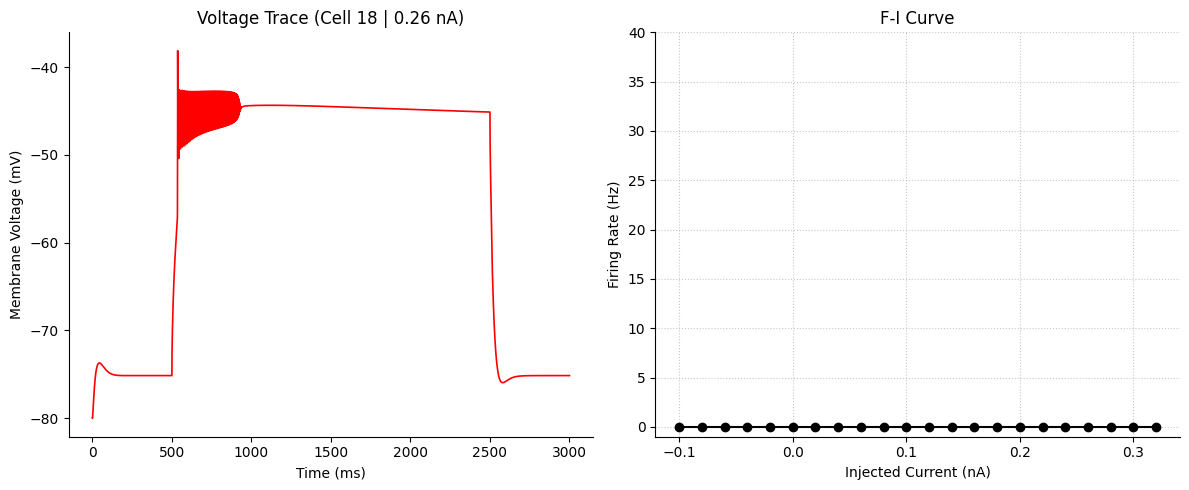

In [171]:
gid_to_amp = {}
for cell in sim.net.allCells:
    gid = cell['gid']
    pop = cell['tags']['pop']
    
    # Find the IClamp amplitude for this specific population
    for clamp in cfg.IClamp:
        if clamp['pop'] == pop:
            gid_to_amp[gid] = clamp['amp']
            break
# ---------------------------------------------------------
# 1. Gather the Data
# ---------------------------------------------------------
spike_times = sim.allSimData['spkt']
spike_gids = sim.allSimData['spkid']
t = sim.allSimData['t']  

start_time = 500  
end_time = 2500    
duration_sec = (end_time - start_time) / 1000.0  

spike_counts = {gid: 0 for gid in gid_to_amp.keys()}

for current_gid, current_time in zip(spike_gids, spike_times):
    if current_time >= start_time and current_time <= end_time:
        if current_gid in spike_counts:
            spike_counts[current_gid] += 1

currents = []
frequencies = []
sorted_gids = sorted(gid_to_amp.keys())

for gid in sorted_gids:
    freq = spike_counts[gid] / duration_sec
    currents.append(gid_to_amp[gid])
    frequencies.append(freq)

# ---------------------------------------------------------
# 2. Create the Subplots
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))



# --- Plot 1: Single Voltage Trace ---
# CHOOSE THE CELL YOU WANT TO SEE HERE (0 to 21):
chosen_gid = 18

# Get the specific trace and the amplitude applied to it
v_trace = sim.allSimData['V_soma']['cell_{}'.format(chosen_gid)]
applied_current = gid_to_amp[chosen_gid]

ax1.plot(t, v_trace, color='red', linewidth=1.2)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Membrane Voltage (mV)')
ax1.set_title(f'Voltage Trace (Cell {chosen_gid} | {applied_current} nA)')

# --- Plot 2: F-I Curve ---
ax2.plot(currents, frequencies, marker='o', color='black', linestyle='-')
ax2.set_xlabel('Injected Current (nA)')
ax2.set_ylabel('Firing Rate (Hz)')
ax2.set_title('F-I Curve')
ax2.set_ylim(-1,40)
ax2.grid(True, linestyle=':', alpha=0.7)


sns.despine()

plt.tight_layout()
plt.show()

In [56]:
sim.allSimData.keys()

dict_keys(['spkt', 'spkid', 'stims', 'V_soma', 't', 'avgRate', 'getdoc', '__wrapped__', '__call__', '_repr_mimebundle_', '_repr_html_', '_repr_markdown_', '_repr_svg_', '_repr_png_', '_repr_pdf_', '_repr_jpeg_', '_repr_latex_', '_repr_json_', '_repr_javascript_'])

In [58]:
allpops

['HL23PYR_1',
 'HL23PYR_2',
 'HL23PYR_3',
 'HL23PYR_4',
 'HL23PYR_5',
 'HL23PYR_6',
 'HL23PYR_7',
 'HL23PYR_8',
 'HL23PYR_9',
 'HL23PYR_10',
 'HL23PYR_11',
 'HL23PYR_12',
 'HL23PYR_13',
 'HL23PYR_14',
 'HL23PYR_15',
 'HL23PYR_16',
 'HL23PYR_17',
 'HL23PYR_18',
 'HL23PYR_19',
 'HL23PYR_20',
 'HL23PYR_21',
 'HL23PYR_22']

In [77]:
sim.net.allCells[0]['tags']

{cellType: 'HL23PYR', cellModel: 'HH_full', pop: 'HL23PYR_1', xnorm: 0.11551505114987608, ynorm: 0.7647656351875594, znorm: 0.9230938465513536, x: 11.551505114987608, y: 76.47656351875594, z: 92.30938465513536, label: ['HL23PYR'], _repr_mimebundle_: {}}

In [ ]:
sim.simData['spkt']

1005.7500000015675

In [28]:
print(f"Type of sim.simData['t']: {type(sim.simData['t'])}")
print(f"Contents of sim.simData['t']: {sim.simData['t']}")


Type of sim.simData['t']: <class 'hoc.HocObject'>
Contents of sim.simData['t']: Vector[71]


In [29]:
import numpy as np

# If time is missing, reconstruct it manually
time = np.arange(0, cfg.duration, cfg.dt)
print(f"Reconstructed time array (first 10 values): {time[:10]}")


Reconstructed time array (first 10 values): [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225]


# **ANALYSIS: Firing Rate Calculation**

In [49]:
sim.simData['spkt'][2]

1006.4500000015701

In [40]:
spk_times = sim.simData['spkt']
spk_ids = sim.simData['spkid']
steps, rates = np.unique(spk_ids, return_counts=True)

In [15]:
print(sim.net.cells)

[compartCell_HL23PYR_HH_full_0, compartCell_HL23PYR_HH_full_1, compartCell_HL23PYR_HH_full_2, compartCell_HL23PYR_HH_full_3, compartCell_HL23PYR_HH_full_4, compartCell_HL23PYR_HH_full_5, compartCell_HL23PYR_HH_full_6, compartCell_HL23PYR_HH_full_7, compartCell_HL23PYR_HH_full_8, compartCell_HL23PYR_HH_full_9, compartCell_HL23PYR_HH_full_10, compartCell_HL23PYR_HH_full_11, compartCell_HL23PYR_HH_full_12, compartCell_HL23PYR_HH_full_13, compartCell_HL23PYR_HH_full_14, compartCell_HL23PYR_HH_full_15, compartCell_HL23PYR_HH_full_16, compartCell_HL23PYR_HH_full_17, compartCell_HL23PYR_HH_full_18, compartCell_HL23PYR_HH_full_19, compartCell_HL23PYR_HH_full_20, compartCell_HL23PYR_HH_full_21]


In [16]:
print(sim.simData['V_soma'].keys())


dict_keys(['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8', 'cell_9', 'cell_10', 'cell_11', 'cell_12', 'cell_13', 'cell_14', 'cell_15', 'cell_16', 'cell_17', 'cell_18', 'cell_19', 'cell_20', 'cell_21'])


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the selected cell
selected_cell = "compartCell_HL23PYR_HH_full_9"  # Adjust based on your naming

# Convert time array to NumPy for indexing
time_array = np.array(sim.simData['t'])

# Define time range
start_time, end_time = 1000, 3000
time_indices = np.where((time_array >= start_time) & (time_array <= end_time))

# Plot voltage trace for the selected cell
if selected_cell in sim.simData['V_soma']:
    plt.figure(figsize=(8, 4))
    plt.plot(time_array[time_indices], np.array(sim.simData['V_soma'][selected_cell])[time_indices], label=f"{selected_cell}")
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    plt.title(f'Voltage Trace for {selected_cell} (1000-3000 ms)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"⚠️ Cell {selected_cell} not found in sim.simData['V_soma']!")

# 🔹 Find the current step applied to cell_9
cell_index = 9  # `HL23PYR_HH_full_9` corresponds to the 9th index

# Check if current steps are defined in `cfg.IClamp`
if hasattr(sim.cfg, 'IClamp') and len(sim.cfg.IClamp) > cell_index:
    applied_current = sim.cfg.IClamp[cell_index]['amp']  # Extract current amplitude
    print(f"📢 Stimulus Amplitude for {selected_cell}: {applied_current} nA")
else:
    print("⚠️ Could not find applied stimulus for this cell!")


⚠️ Cell compartCell_HL23PYR_HH_full_9 not found in sim.simData['V_soma']!
📢 Stimulus Amplitude for compartCell_HL23PYR_HH_full_9: 0.06999999999999999 nA


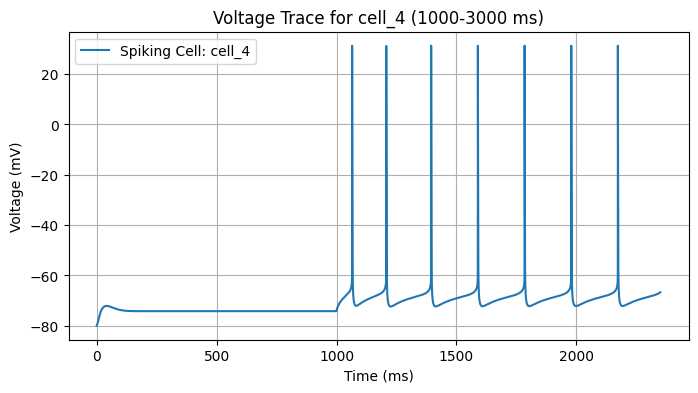

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.figure(figsize=(8, 4))

# Define time range
start_time, end_time = 0, 3000

# Convert time array to NumPy for indexing
time_array = np.array(sim.simData['t'])

# Find indices corresponding to the desired time range
time_indices = np.where((time_array >= start_time) & (time_array <= end_time))

# Find a cell that spikes
spiking_cell = None
available_cells = list(sim.simData['V_soma'].keys())

for cell in available_cells:
    voltage_trace = np.array(sim.simData['V_soma'][cell])  # Convert to NumPy array
    peaks, _ = find_peaks(voltage_trace, height=-20)  # Detect spikes above -20 mV
    if len(peaks) > 0:  # If this cell has spikes, select it
        spiking_cell = cell
        break

# Plot the voltage trace of the spiking cell
if spiking_cell:
    plt.plot(time_array[time_indices], np.array(sim.simData['V_soma'][spiking_cell])[time_indices], label=f"Spiking Cell: {spiking_cell}")
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    plt.title(f'Voltage Trace for {spiking_cell} (1000-3000 ms)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("⚠️ No spiking cells found in sim.simData['V_soma']!")


In [19]:
import matplotlib.pyplot as plt

# Plot the 3D morphology
sim.analysis.plotShape(
    showSyns=False,   # Show synapses if True
    showConns=False,  # Show connectivity if True
    includePre=False, # Include presynaptic cells if needed
    figSize=(8, 8), 
    saveFig=False
)

# Force display if running in Jupyter Notebook
plt.show()


Plotting 3D cell shape ...


In [74]:
import matplotlib.pyplot as plt
%matplotlib inline

# Ensure the network has been initialized
if not hasattr(sim, 'net'):
    raise ValueError("⚠️ Network is not initialized. Run `sim.createSimulateAnalyze()` first!")

# Plot the morphology
sim.analysis.plotShape(showSyns=False, showConns=False, includePre=False, figSize=(10, 10))

# Show the figure
plt.show()


Plotting 3D cell shape ...


Raster Plot of Spiking

In [73]:
# import matplotlib.pyplot as plt

# # Generate raster plot
# sim.analysis.plotRaster()
# plt.show()


Connectivity Matrix

In [71]:
# import matplotlib.pyplot as plt

# # Plot connectivity matrix (NetPyNE automatically includes all available populations)
# sim.analysis.plotConn(feature='strength', figSize=(8, 8))
# plt.show()


Connectivity Diagram

In [72]:
# # Plot connectivity diagram
# sim.analysis.plot2Dnet(include=allpops, showConns=True)
# plt.show()


# **PLOT: F-I Curve**

In [42]:
from scipy.stats import linregress

# Ensure current_start is correctly defined before running regression
current_start = 0.0  # nA (example, adjust as needed)
current_step = 0.015  # nA step
steps = np.arange(len(rates))  # Ensure steps is an array

# Compute linear regression on the F-I curve
slope, intercept, r_value, p_value, std_err = linregress(current_start + steps * current_step, rates / 0.8)

print(f"F-I Curve Slope: {slope:.3f} Hz/nA")
print(f"Intercept: {intercept:.3f} Hz")
print(f"R-squared: {r_value**2:.3f}")


F-I Curve Slope: 85.225 Hz/nA
Intercept: 13.231 Hz
R-squared: 0.957


In [43]:
rates

array([ 7, 11, 13, 14, 15, 17, 18, 19, 20, 20, 21, 22, 23, 24, 25, 25, 26,
       27])

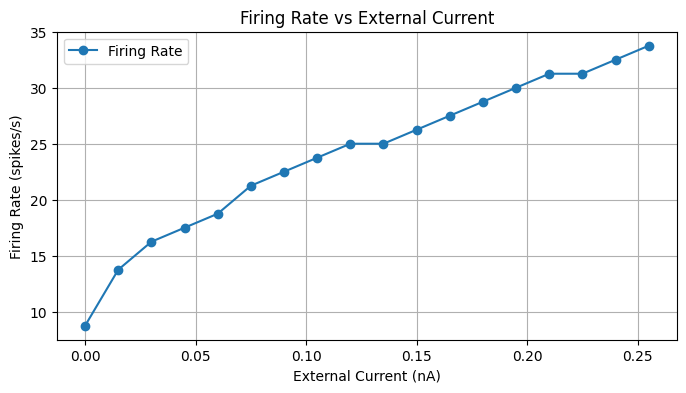

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(current_start + steps * current_step, rates / 0.8, marker='o', label='Firing Rate')
plt.xlabel('External Current (nA)')
plt.ylabel('Firing Rate (spikes/s)')
plt.title('Firing Rate vs External Current')
plt.grid(True)
plt.legend()
plt.show()

In [70]:
import numpy as np

# Extract spike times and IDs
spike_times = np.array(sim.simData['spkt'])  # Spike times
spike_ids = np.array(sim.simData['spkid'])  # Corresponding cell IDs

# Define current steps (-110 pA to 310 pA in 20 pA increments)
current_steps = np.arange(-110, 320, 20)  # pA

# Identify the first current step that reliably produces a spike
for i, current in enumerate(current_steps):
    spikes_at_current = np.any(spike_ids == i)  # Check if any cell spikes at this current
    if spikes_at_current:
        rheobase = current
        break

print(f"✅ Corrected Rheobase: {rheobase} pA")


✅ Corrected Rheobase: 70 pA


# **PLOT: V-I Curve (Sag)**

In [31]:
# Compute Sag Values for each cell
sag_values = []

for cell in sim.simData['V_soma']:
    V_soma = np.array(sim.simData['V_soma'][cell])  # Convert to NumPy array
    t = np.array(sim.simData['t'])  # Time array

    # Define hyperpolarization window
    V_min = V_soma[(t >= 1200) & (t < 2200)].min()  # Minimum voltage during hyperpolarization
    V_ss = V_soma[t >= 2200][-1]  # Steady-state voltage

    sag = V_ss - V_min
    sag_values.append(sag)

# Now `sag_values` exists, so you can iterate over it
for i, amp in enumerate(np.linspace(-0.110, 0.5, len(sag_values))):
    print(f"Injected Current: {amp:.3f} nA | Sag: {sag_values[i]:.3f} mV")


Injected Current: -0.110 nA | Sag: 0.790 mV
Injected Current: -0.081 nA | Sag: 0.613 mV
Injected Current: -0.052 nA | Sag: 0.453 mV
Injected Current: -0.023 nA | Sag: 0.308 mV
Injected Current: 0.006 nA | Sag: 0.176 mV
Injected Current: 0.035 nA | Sag: 0.057 mV
Injected Current: 0.064 nA | Sag: 0.767 mV
Injected Current: 0.093 nA | Sag: 2.505 mV
Injected Current: 0.122 nA | Sag: 5.426 mV
Injected Current: 0.151 nA | Sag: 10.127 mV
Injected Current: 0.180 nA | Sag: 3.785 mV
Injected Current: 0.210 nA | Sag: 2.148 mV
Injected Current: 0.239 nA | Sag: 4.148 mV
Injected Current: 0.268 nA | Sag: 5.881 mV
Injected Current: 0.297 nA | Sag: 7.045 mV
Injected Current: 0.326 nA | Sag: 7.636 mV
Injected Current: 0.355 nA | Sag: 7.704 mV
Injected Current: 0.384 nA | Sag: 7.473 mV
Injected Current: 0.413 nA | Sag: 7.148 mV
Injected Current: 0.442 nA | Sag: 6.838 mV
Injected Current: 0.471 nA | Sag: 6.578 mV
Injected Current: 0.500 nA | Sag: 6.406 mV


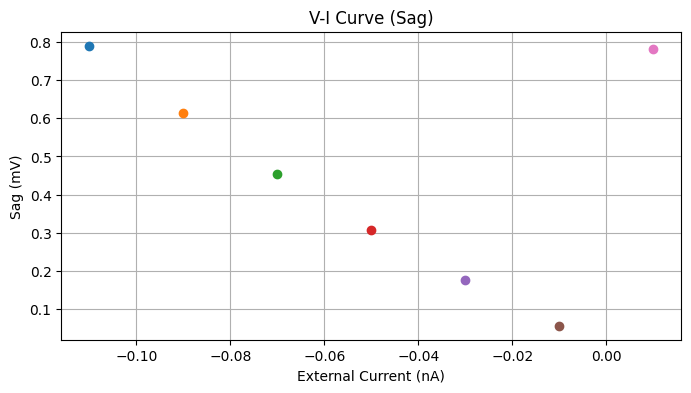

In [32]:
plt.figure(figsize=(8, 4))
plt.grid(True)

for steps, cellName in enumerate(list(sim.simData['V_soma'].keys())[:7]):
    if 'cell' in cellName:
        plt.plot(current_start + steps * current_step, list(sim.simData['V_soma'][cellName])[80000] - np.min(list(sim.simData['V_soma'][cellName])[40000:80000]), 'o')

plt.ylabel('Sag (mV)')
plt.xlabel('External Current (nA)')
plt.title("V-I Curve (Sag)")
plt.grid(True)
plt.show()


# **PLOT: Voltage Traces**

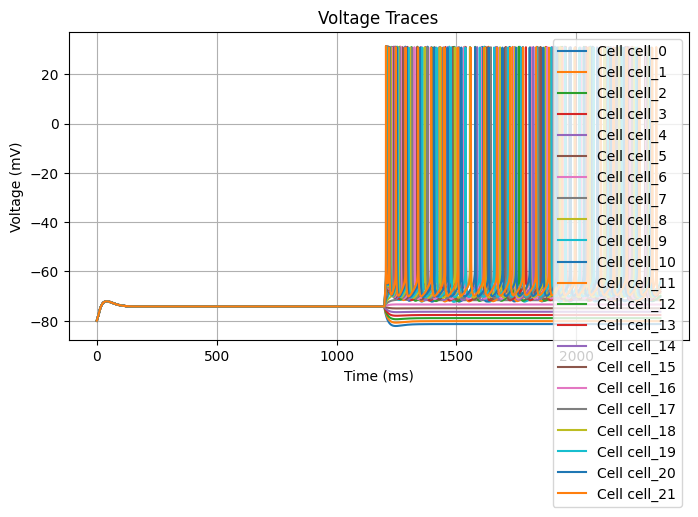

In [33]:
plt.figure(figsize=(8, 4))
for cellName in sim.simData['V_soma'].keys():
    plt.plot(sim.simData['t'], sim.simData['V_soma'][cellName], label=f"Cell {cellName}")

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Voltage Traces')
plt.legend()
plt.grid(True)
plt.show()

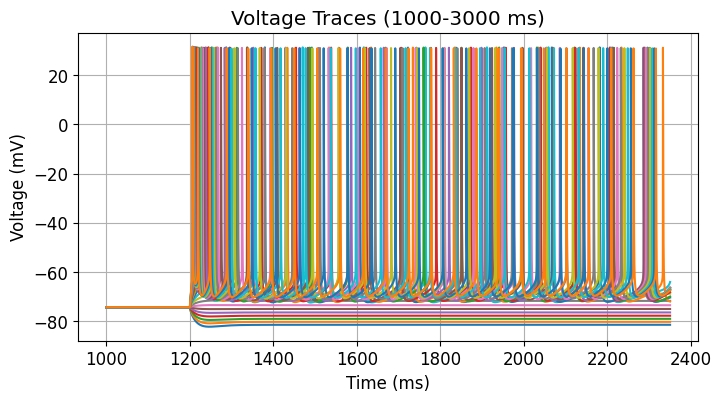

In [61]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))

# Define time range
start_time, end_time = 1000, 3000

# Convert time array to NumPy for indexing
time_array = np.array(sim.simData['t'])

# Find indices corresponding to the desired time range
time_indices = np.where((time_array >= start_time) & (time_array <= end_time))

# Plot voltage traces for all cells in the given time range
for cellName in sim.simData['V_soma'].keys():
    plt.plot(time_array[time_indices], np.array(sim.simData['V_soma'][cellName])[time_indices], label=f"Cell {cellName}")

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title(f'Voltage Traces ({start_time}-{end_time} ms)')
# plt.legend()
plt.grid(True)
plt.show()


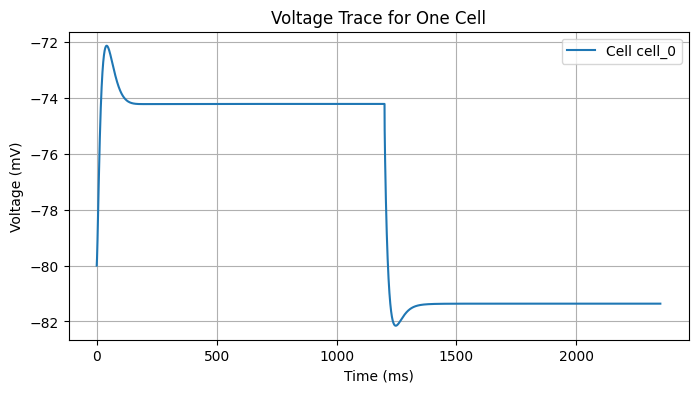

In [34]:
plt.figure(figsize=(8, 4))
cellName = list(sim.simData['V_soma'].keys())[0]  # Select the first cell
plt.plot(sim.simData['t'], sim.simData['V_soma'][cellName], label=f"Cell {cellName}")
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Voltage Trace for One Cell')
plt.legend()
plt.grid(True)
plt.show()


# ***PHYSIOLOGICAL PROPERTIES***

# *(a) Resting Membrane Potential (V_rest)*

In [35]:
import numpy as np
from netpyne import sim  # Ensure sim is imported

V_rest = []

for cell in sim.simData['V_soma']:
    V_soma = np.array(sim.simData['V_soma'][cell])
    t = np.array(sim.simData['t'])

    # Extract resting potential from the first 200 ms
    V_rest.append(np.mean(V_soma[t < 200]))

# Compute average resting potential across cells
print(f"Resting Membrane Potential: {np.mean(V_rest):.3f} mV")



Resting Membrane Potential: -73.870 mV


# *(b) Spike Threshold*

In [36]:
from scipy.signal import find_peaks

# Detect peaks (spikes) and estimate threshold as min voltage before peak
spike_thresholds = []
for cell in sim.simData['V_soma']:
    v = np.array(sim.simData['V_soma'][cell])
    peaks, _ = find_peaks(v, height=-20)  # Spikes above -20mV
    if len(peaks) > 0:
        spike_thresholds.append(np.min(v[peaks]))  # Minimum before peak

print(f"Spike Threshold: {np.mean(spike_thresholds):.3f} mV")


Spike Threshold: 30.956 mV


# *(c) Spike Half-Width*

In [37]:
spike_half_widths = []
for cell in sim.simData['V_soma']:
    v = np.array(sim.simData['V_soma'][cell])
    peaks, _ = find_peaks(v, height=-20)
    if len(peaks) > 0:
        half_max = (np.max(v[peaks]) + np.min(v[peaks])) / 2
        spike_half_widths.append(np.sum(v > half_max) * sim.cfg.dt)

print(f"Spike Half-Width: {np.mean(spike_half_widths):.3f} ms")


Spike Half-Width: 0.088 ms


# *(d) Spike Amplitude*

In [38]:
import numpy as np

spike_amplitudes = []

for cell in sim.simData['V_soma']:
    V_soma = np.array(sim.simData['V_soma'][cell])  # Ensure it's a NumPy array
    if V_soma.size > 0:  # Check if data is not empty
        spike_amplitudes.append(np.max(V_soma) - np.min(V_soma))

if spike_amplitudes:
    print(f"Spike Amplitude: {np.mean(spike_amplitudes):.3f} mV")
else:
    print("No spikes detected.")


Spike Amplitude: 69.353 mV


# *(e) Spike Width*

In [39]:
spike_widths = [np.ptp(sim.simData['V_soma'][cell]) for cell in sim.simData['V_soma']]
print(f"Spike Width: {np.mean(spike_widths):.3f} ms")


Spike Width: 69.353 ms


# *(f) AHP Amplitude*

In [40]:
ahp_amplitudes = []
for cell in sim.simData['V_soma']:
    v = np.array(sim.simData['V_soma'][cell])
    peaks, _ = find_peaks(v, height=-20)
    if len(peaks) > 0:
        ahp_amplitudes.append(np.min(v[peaks]) - np.mean(V_rest))

print(f"AHP Amplitude: {np.mean(ahp_amplitudes):.3f} mV")


AHP Amplitude: 104.826 mV


# *(g) AHP Duration*

In [41]:
AHP_durations = []

for cell in sim.simData['V_soma']:
    V_soma = np.array(sim.simData['V_soma'][cell])
    t = np.array(sim.simData['t'])
    peaks, _ = find_peaks(V_soma, height=-20)

    if len(peaks) > 0:
        peak_idx = peaks[np.argmax(V_soma[peaks])]  # Get index of max spike peak
        
        # Define a STRICTER search window (~15–20 ms after the peak)
        search_window = (t >= t[peak_idx]) & (t <= t[peak_idx] + 20)

        if np.any(search_window):
            V_soma_segment = V_soma[search_window]
            t_segment = t[search_window]

            if len(V_soma_segment) > 0:
                trough_idx = np.argmin(V_soma_segment)  # Local minimum
                AHP_duration = t_segment[trough_idx] - t[peak_idx]  # Duration in ms

                if AHP_duration > 2:  # Ignore unrealistic AHP durations <2 ms
                    AHP_durations.append(AHP_duration)

if AHP_durations:
    print(f"Refined AHP Duration: {np.mean(AHP_durations):.3f} ms")
else:
    print("No valid AHP detected.")


Refined AHP Duration: 13.879 ms
